Silhouette Score: 0.5268


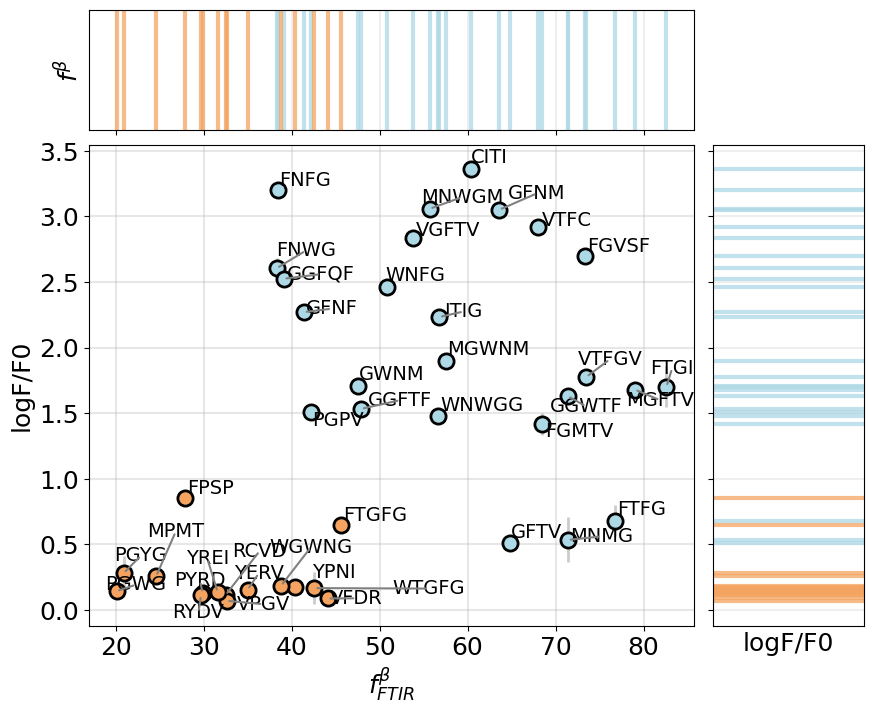

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import matplotlib.lines as mlines
from adjustText import adjust_text

# 1. Load and merge data
df_sum = pd.read_csv('sum_complie_all.csv')
df_tht = pd.read_csv('tht_60.csv')

col_pep_sum = df_sum.columns[0]
col_pep_tht = df_tht.columns[0]
col_beta = df_sum.columns[1]
col_log = 'logF/F0'
col_sem = 'sem_log'

df = pd.merge(df_sum, df_tht, left_on=col_pep_sum, right_on=col_pep_tht)
df_clean = df.dropna(subset=[col_beta, col_log]).copy()




df_tri = df_clean[df_clean[col_pep_sum].astype(str).str.strip().str.len() > 3].copy()
df_clean = df_tri

# Raw feature matrix
X_raw = df_clean[[col_beta, col_log]].values

# 2. Standardize the data for fair model training
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --- REPLACED K-MEANS WITH SPECTRAL CLUSTERING ---
# Using the RBF kernel to build the affinity graph. 
# 'gamma' controls the kernel width; default is 1.0 but can be tuned.
# already tried gmma = 0.1 and 5.0, the same outcome
spectral = SpectralClustering(n_clusters=2, affinity='rbf', gamma=1.0, random_state=42)
y_spectral = spectral.fit_predict(X_scaled)
df_clean['cluster'] = y_spectral

from sklearn.metrics import silhouette_score

# Calculate the silhouette score using the scaled data and the cluster labels
sil_score = silhouette_score(X_scaled, y_spectral)

print(f"Silhouette Score: {sil_score:.4f}")

from sklearn.metrics import silhouette_samples

# Calculate individual silhouette scores for every data point
df_clean["sil_individual"] = silhouette_samples(X_scaled, y_spectral)

# smallest 15%
#threshold_sil = np.percentile(df_clean["sil_individual"], 15)
#df_clean["is_boundary"] = df_clean["sil_individual"] <= threshold_sil

df_clean['is_boundary'] = df_clean['sil_individual'] <= 0.25
df_boundary = df_clean[df_clean["is_boundary"] == True]

# Export source data: seq, coordinates, and cluster category
source_df = pd.DataFrame({
    'seq': df_clean[col_pep_sum].astype(str).str.strip().values,
    col_beta: df_clean[col_beta].values,
    col_log: df_clean[col_log].values,
    'category': df_clean['cluster'].values,
})
source_df.to_csv('SourceData.csv', index=False)

# Train the SVM on the Spectral labels purely to generate the continuous 
# decision boundary and extract the structural Support Vectors for plotting.
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_scaled, y_spectral)

# 3. Plotting in ORIGINAL space with marginal rug plots
plt.rcParams.update({
    'font.size': 18,
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
})

fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                      wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

cluster_colors = {1: 'sandybrown', 0: 'lightblue'}

# Top marginal: vertical lines at each f^beta value
for i, (x, y) in enumerate(X_raw):
    ax_top.axvline(x, color=cluster_colors[y_spectral[i]], alpha=0.75, linewidth=3)

# Right marginal: horizontal lines at each logF/F0 value
for i, (x, y) in enumerate(X_raw):
    ax_right.axhline(y, color=cluster_colors[y_spectral[i]], alpha=0.75, linewidth=3)

# Error bars using original raw SEM
ax_main.errorbar(X_raw[:, 0], X_raw[:, 1], yerr=df_clean[col_sem],
                 fmt='none', ecolor='gray', alpha=0.4, elinewidth=2, zorder=1)

# Scatter points in original space
ax_main.scatter(X_raw[y_spectral == 0, 0], X_raw[y_spectral == 0, 1],
                color='lightblue', s=120, edgecolor='k', linewidths=2, zorder=2)
ax_main.scatter(X_raw[y_spectral == 1, 0], X_raw[y_spectral == 1, 1],
                color='sandybrown', s=120, edgecolor='k', linewidths=2, zorder=2)

# 4. Plot SVM decision boundary and margins projected onto original space
ax = ax_main
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid in the ORIGINAL scale
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)

# Transform the original space grid points into the scaled space for SVM evaluation
xy_raw = np.vstack([XX.ravel(), YY.ravel()]).T
xy_scaled = scaler.transform(xy_raw)

# Get the decision boundaries from the SVM
Z = svm_model.decision_function(xy_scaled).reshape(XX.shape)

# Draw the contour lines back onto the ORIGINAL axes
#ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.7,
#           linestyles=['--', '-', '--'], linewidths=[1.5, 2, 1.5])
           
# Inverse transform the Support Vectors so they plot correctly over the raw points
#sv_raw = scaler.inverse_transform(svm_model.support_vectors_)
#ax.scatter(sv_raw[:, 0], sv_raw[:, 1], s=200,
#           linewidth=1.5, facecolors='none', edgecolors='k', zorder=3)

#ax_main.scatter(
#    df_boundary[col_beta],
#    df_boundary[col_boundary_log if "col_boundary_log" in locals() else col_log],
#    facecolors="none",
#    edgecolors="green",
#    linewidths=3,
#    s=200,
#    label="Boundary Points (Low Silhouette)",
#)

# 5. Add Text Labels using original coordinates (skip tripeptides)
texts = []
for i, row in df_clean.iterrows():
    seq = str(row[col_pep_sum]).strip()
    if len(seq) == 3:
        continue
    texts.append(ax_main.text(row[col_beta], row[col_log], seq, fontsize=14))

# Repel overlapping labels
adjust_text(texts,
            ax=ax_main,
            arrowprops=dict(arrowstyle='-', color='gray', lw=1.5),
            expand_points=(1.2, 1.2),
            expand_text=(1.2, 1.2))

# Style marginal axes
ax_top.set_ylabel(r'$f^{\beta}$', fontsize=18)
ax_top.tick_params(axis='x', labelbottom=False)
ax_top.set_yticks([])
ax_top.grid(True, alpha=0.2, axis='x', linewidth=1.5)

ax_right.set_xlabel('logF/F0', fontsize=18)
ax_right.tick_params(axis='y', labelleft=False)
ax_right.set_xticks([])
ax_right.grid(True, alpha=0.2, axis='y', linewidth=1.5)

ax_main.set_xlabel(r'$f^{\beta}_{FTIR}$', fontsize=18)
ax_main.set_ylabel('logF/F0', fontsize=18)
#ax_main.set_title('Spectral Clustering (RBF) Decision Boundary', fontsize=18)

# Legend
cluster1_patch = mlines.Line2D([], [], color='sandybrown', marker='o', linestyle='None', markersize=12, markeredgecolor='k', markeredgewidth=2, label='Cluster 1')
cluster2_patch = mlines.Line2D([], [], color='lightblue', marker='o', linestyle='None', markersize=12, markeredgecolor='k', markeredgewidth=2, label='Cluster 2')
sv_patch = mlines.Line2D([], [], color='none', marker='o', linestyle='None', markersize=14, markeredgecolor='k', markeredgewidth=2, label='Support Vectors')
#db_line = mlines.Line2D([], [], color='k', linestyle='-', linewidth=2, label='Decision Boundary')

#ax_main.legend(handles=[cluster1_patch, cluster2_patch, sv_patch, db_line])
ax_main.grid(True, alpha=0.3, linewidth=1.5)

# High resolution save exactly as requested
plt.savefig("cat_tri_tet_pent.png", dpi=300, bbox_inches='tight')
plt.show()